In [1]:
print('Hello World!')

Hello World!


In [2]:
import time
time.sleep(3)

In [3]:
import numpy as np
def square(x):
    return x * x

In [4]:
x = np.random.randint(1, 10)
y = square(x)
print('%d squared is %d' % (x, y))

1 squared is 1


In [5]:
numbers = [64, 25, 12, 22, 11]

def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i+1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    return arr

In [6]:
def test():
    sorted_numbers = selection_sort(numbers.copy())
    print("排序前:", numbers)
    print("排序后:", sorted_numbers)

test()

排序前: [64, 25, 12, 22, 11]
排序后: [11, 12, 22, 25, 64]


In [12]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('fortune500.csv')

In [14]:
df.head()

,Year,Rank,Company,Revenue (in millions),Profit (in millions)
0,1955,1,General Motors,9823.5,806
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1


In [15]:
df.tail()

,Year,Rank,Company,Revenue (in millions),Profit (in millions)
25495,2005,496,Wm. Wrigley Jr.,3648.6,493
25496,2005,497,Peabody Energy,3631.6,175.4
25497,2005,498,Wendy's International,3630.4,57.8
25498,2005,499,Kindred Healthcare,3616.6,70.6
25499,2005,500,Cincinnati Financial,3614.0,584


In [16]:
df.columns = ['year', 'rank', 'company', 'revenue', 'profit']

In [17]:
len(df)

25500

In [18]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit      object
dtype: object

In [19]:
non_numberic_profits = df.profit.str.contains('[^0-9.-]')
df.loc[non_numberic_profits].head()

,year,rank,company,revenue,profit
228,1955,229,Norton,135.0,N.A.
290,1955,291,Schlitz Brewing,100.0,N.A.
294,1955,295,Pacific Vegetable Oil,97.9,N.A.
296,1955,297,Liebmann Breweries,96.0,N.A.
352,1955,353,Minneapolis-Moline,77.4,N.A.


In [20]:
len(df.profit[non_numberic_profits])

369

In [22]:
non_numberic_profits = df.profit.str.contains('[^0-9.-]')
df = df.loc[~non_numberic_profits]
df.profit = df.profit.apply(pd.to_numeric)

In [23]:
len(df)

25131

In [24]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit     float64
dtype: object

In [25]:
group_by_year = df.loc[:, ['year', 'revenue', 'profit']].groupby('year')
avgs = group_by_year.mean()
x = avgs.index
y_profit = avgs.profit
y_revenue = avgs.revenue

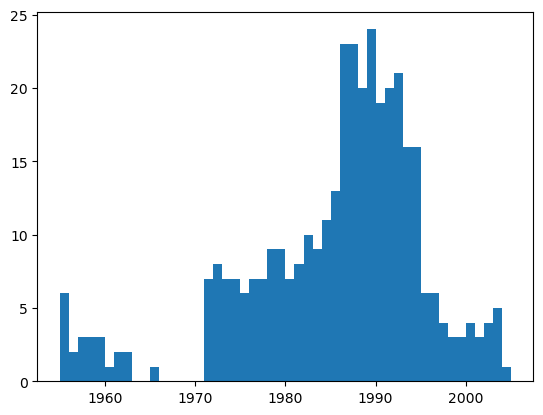

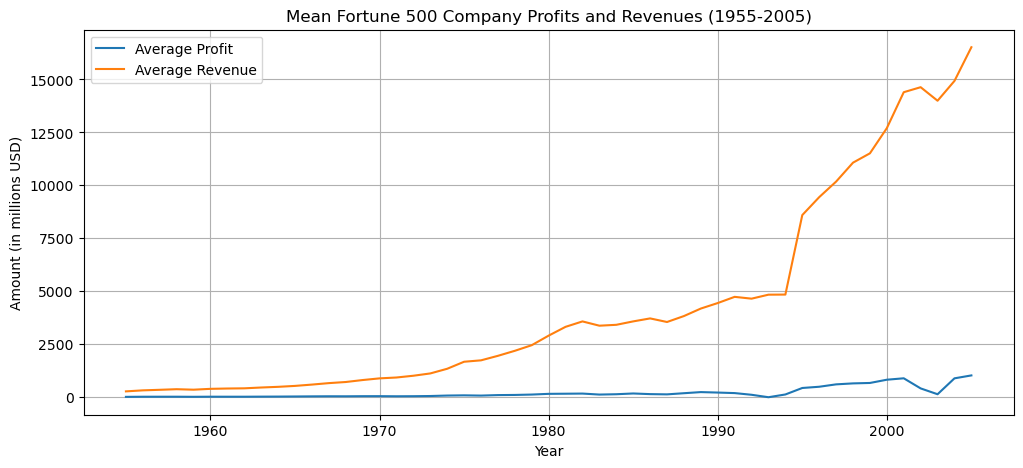

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(x, y_profit, label='Average Profit')
plt.plot(x, y_revenue, label='Average Revenue')
plt.title('Mean Fortune 500 Company Profits and Revenues (1955-2005)')
plt.xlabel('Year')
plt.ylabel('Amount (in millions USD)')
plt.legend()
plt.grid(True)
plt.show()